<a href="https://colab.research.google.com/github/VarizkyNaldiba/ML_Ganjil_2025/blob/main/Kelompok_6_TI_3E_Quiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intialization
just one time to execute this

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_sets = {
  "Beetroot": ["Beetroot 1"],
  "Cabbage-Red": ["Cabbage red 1"],
  "Carrot": ["Carrot 1"],
  "Cauliflower": ["Cauliflower 1"],
  "Ginger-Root": ["Ginger Root 1"],

  "Kohlrabi": ["Kohlrabi 1"],
  "Onion-Red": ["Onion Red 1", "Onion Red 2"],
  "Onion-White": ["Onion White 1"],
  "Potato-Red": ["Potato Red 1"],
  "Potato-Sweet": ["Potato Sweet 1"],

  "Potato-White": ["Potato White 1"],
  "Granadilla": ["Granadilla 1"],
  "Maracuja": ["Maracuja 1"],
  "Passion-Fruit": ["Passion Fruit 1"],
  "Plum": ["Plum 1", "Plum 2", "Plum 3"],
  "Watermelon": ["Watermelon 1"]
}

## JUST ONCE!!

### Retrieve Dataset

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [ ]:
!kaggle datasets download -d moltean/fruits

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 4.52G/4.54G [01:07<00:00, 78.2MB/s]
100% 4.54G/4.54G [01:07<00:00, 71.8MB/s]


In [ ]:
!unzip fruits.zip

Streaming output truncated to the last 5000 lines.
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Quince 3/r2_157.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Quince 3/r2_161.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Quince 3/r2_165.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Quince 3/r2_169.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Quince 3/r2_17.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Quince 3/r2_173.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Quince 3/r2_177.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Quince 3/r2_181.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Quince 3/r2_185.jpg  
  inflating: fruits-360_original-size/fruits-360-original-size/Validation/Quince 3/r2_

### Separating & Move Dataset

In [ ]:
import os
import shutil

os.mkdir("/content/drive/MyDrive/ML-Quiz/datasets") if not os.path.exists("/content/drive/MyDrive/ML-Quiz/datasets") else None
for types in ["Test", "Training"]:
  os.mkdir(f"/content/drive/MyDrive/ML-Quiz/datasets/{types}") if not os.path.exists(f"/content/drive/MyDrive/ML-Quiz/datasets/{types}") else None
  for classification, data_set in data_sets.items():
    destination_dir = f"/content/drive/MyDrive/ML-Quiz/datasets/{types}/{classification}"
    os.mkdir(destination_dir) if not os.path.exists(destination_dir) else None
    for data in data_set:
      source_file_path = os.path.join("/content/fruits-360_100x100/fruits-360/", types, data)
      print(f"{types}/{classification}/{data}")
      shutil.copytree(source_file_path, destination_dir, dirs_exist_ok=True)

Test/Beetroot/Beetroot 1


FileNotFoundError: [Errno 2] No such file or directory: '/content/fruits-360_100x100/fruits-360/Test/Beetroot 1'

# QUIZ ML ( 1 CLICK )

In [ ]:
data_sets = {
  "Beetroot": ["Beetroot 1"],
  "Cabbage-Red": ["Cabbage red 1"],
  "Carrot": ["Carrot 1"],
  "Cauliflower": ["Cauliflower 1"],
  "Ginger-Root": ["Ginger Root 1"],

  "Kohlrabi": ["Kohlrabi 1"],
  "Onion-Red": ["Onion Red 1", "Onion Red 2"],
  "Onion-White": ["Onion White 1"],
  "Potato-Red": ["Potato Red 1"],
  "Potato-Sweet": ["Potato Sweet 1"],

  "Potato-White": ["Potato White 1"],
  "Granadilla": ["Granadilla 1"],
  "Maracuja": ["Maracuja 1"],
  "Passion-Fruit": ["Passion Fruit 1"],
  "Plum": ["Plum 1", "Plum 2", "Plum 3"],
  "Watermelon": ["Watermelon 1"]
}

## Preprocessing


In [ ]:
from PIL import Image
import numpy as np

def preprocess_image(image_path):
    try:
        img = Image.open(image_path)
        img_array = np.array(img)
        img_array = img_array / 255.0
        return img_array
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        return None
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

print("Image preprocessing function `preprocess_image` defined.")

Image preprocessing function `preprocess_image` defined.


In [ ]:
import os
import numpy as np
from tqdm import tqdm

X_Clean = []
Y_Clean = []

trainingData = '/content/drive/MyDrive/ML-Quiz/datasets/Training'

print(f"Starting preprocessing of training data from: {trainingData}")

for classification in data_sets.keys():
    classification_dir = os.path.join(trainingData, classification)
    if os.path.exists(classification_dir):
        image_files = os.listdir(classification_dir)
        print(f"Processing {len(image_files)} images for category: {classification}")
        for image_file in tqdm(image_files, desc=f"Preprocessing {classification}"):
            image_path = os.path.join(classification_dir, image_file)
            processed_image = preprocess_image(image_path)
            if processed_image is not None:
                X_Clean.append(processed_image)
                Y_Clean.append(classification)
    else:
        print(f"Warning: Directory not found for classification: {classification_dir}")

X_Clean = np.array(X_Clean)
Y_Clean = np.array(Y_Clean)

print(f"\nFinished preprocessing training data.")
print(f"Shape of X_Clean: {X_Clean.shape}")
print(f"Shape of Y_Clean: {Y_Clean.shape}")

Starting preprocessing of training data from: /content/drive/MyDrive/ML-Quiz/datasets/Training
Processing 450 images for category: Beetroot


Preprocessing Beetroot: 100%|██████████| 450/450 [00:08<00:00, 50.84it/s] 


Processing 149 images for category: Cabbage-Red


Preprocessing Cabbage-Red: 100%|██████████| 149/149 [00:04<00:00, 36.77it/s]


Processing 151 images for category: Carrot


...

Processing 1067 images for category: Plum


Preprocessing Plum: 100%|██████████| 1067/1067 [00:20<00:00, 52.26it/s] 


Processing 475 images for category: Watermelon


Preprocessing Watermelon: 100%|██████████| 475/475 [00:08<00:00, 53.73it/s] 



Finished preprocessing training data.
Shape of X_Clean: (8076, 100, 100, 3)
Shape of Y_Clean: (8076,)


## Pretrain/Ekstraksi fitur dengan DeepLearning model MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
from tqdm import tqdm

mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(100, 100, 3))

/tmp/ipython-input-2687249345.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(100, 100, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def extract_features_dl(img_array):
    """
    Ekstraksi fitur dari gambar menggunakan MobileNetV2 pretrained.

    Args:
        img_array (numpy.ndarray): Gambar dengan shape (H, W, 3)
    Returns:
        numpy.ndarray: Vektor fitur berukuran 1280
    """
    img_array = img_array.astype('float32')
    img_batch = np.expand_dims(img_array, axis=0)
    img_batch = preprocess_input(img_batch)

    features = mobilenet.predict(img_batch, verbose=0)
    return features.flatten()

In [ ]:
X_train_features = []
for img_array in tqdm(X_Clean, desc="Extracting features for X_train"):
    X_train_features.append(extract_features_dl(img_array))

X_train_features = np.array(X_train_features)

print(f"Shape of X_train_features: {X_train_features.shape}")

Extracting features for X_train: 100%|██████████| 8076/8076 [11:52<00:00, 11.33it/s]

Shape of X_train_features: (8076, 1280)


## split Data


In [ ]:
from sklearn.model_selection import train_test_split

X_train_split, X_test_split, Y_train_split, Y_test_split = train_test_split(
    X_train_features, Y_Clean, test_size=0.2, random_state=42
)

print(f"Shape of X_train_split: {X_train_split.shape}")
print(f"Shape of X_test_split: {X_test_split.shape}")
print(f"Shape of Y_train_split: {Y_train_split.shape}")
print(f"Shape of Y_test_split: {Y_test_split.shape}")

Shape of X_train_split: (6460, 1280)
Shape of X_test_split: (1616, 1280)
Shape of Y_train_split: (6460,)
Shape of Y_test_split: (1616,)


## Reduksi Dimensi dan standarisasi(standard scaler)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_test_scaled = scaler.transform(X_test_split)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original shape of X_train_split: {X_train_split.shape}")
print(f"Shape of X_train_pca after PCA: {X_train_pca.shape}")
print(f"Shape of X_test_pca after PCA: {X_test_pca.shape}")
print(f"Number of components retained: {pca.n_components_}")

Original shape of X_train_split: (6460, 1280)
Shape of X_train_pca after PCA: (6460, 88)
Shape of X_test_pca after PCA: (1616, 88)
Number of components retained: 88


## Hyperparameter tuning


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"]
}

svm = SVC(random_state=42)

grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("Running GridSearch Tuning...")
grid.fit(X_train_pca, Y_train_split)

print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_

Running GridSearch Tuning...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


## lakukan pengolahan yang sama dengan data train pada data test, hingga reduksi dimensi, untuk persiapan evaluasi model

In [ ]:
import os
import numpy as np
from tqdm import tqdm

X_test_Clean = []
Y_test_Clean = []

testData = '/content/drive/MyDrive/ML-Quiz/datasets/Test'

print(f"Starting preprocessing of test data from: {testData}")

for classification in data_sets.keys():
    classification_dir = os.path.join(testData, classification)
    if os.path.exists(classification_dir):
        image_files = os.listdir(classification_dir)
        print(f"Processing {len(image_files)} images for category: {classification}")
        for image_file in tqdm(image_files, desc=f"Preprocessing {classification}"):
            image_path = os.path.join(classification_dir, image_file)
            processed_image = preprocess_image(image_path)
            if processed_image is not None:
                X_test_Clean.append(processed_image)
                Y_test_Clean.append(classification)
    else:
        print(f"Warning: Directory not found for classification: {classification_dir}")

X_test_Clean = np.array(X_test_Clean)
Y_test_Clean = np.array(Y_test_Clean)

print(f"\nFinished preprocessing test data.")
print(f"Shape of X_test_Clean: {X_test_Clean.shape}")
print(f"Shape of Y_test_Clean: {Y_test_Clean.shape}")

Starting preprocessing of test data from: /content/drive/MyDrive/ML-Quiz/datasets/Test
Processing 150 images for category: Beetroot


Preprocessing Beetroot: 100%|██████████| 150/150 [00:02<00:00, 55.52it/s] 


Processing 49 images for category: Cabbage-Red


Preprocessing Cabbage-Red: 100%|██████████| 49/49 [00:14<00:00,  3.49it/s]


Processing 50 images for category: Carrot


...

Processing 476 images for category: Plum


Preprocessing Plum: 100%|██████████| 476/476 [00:09<00:00, 50.08it/s] 


Processing 157 images for category: Watermelon


Preprocessing Watermelon: 100%|██████████| 157/157 [00:02<00:00, 76.71it/s] 



Finished preprocessing test data.
Shape of X_test_Clean: (2839, 100, 100, 3)
Shape of Y_test_Clean: (2839,)


In [ ]:
X_test_features = []
for img_array in tqdm(X_test_Clean, desc="Extracting features for X_test"):
    X_test_features.append(extract_features_dl(img_array))

X_test_features = np.array(X_test_features)

print(f"Shape of X_test_features: {X_test_features.shape}")

Extracting features for X_test: 100%|██████████| 2839/2839 [04:20<00:00, 10.92it/s]

Shape of X_test_features: (2839, 1280)


In [ ]:
X_test_scaled_for_pca = scaler.transform(X_test_features)
X_test_pca = pca.transform(X_test_scaled_for_pca)

print(f"Original shape of X_test_features: {X_test_features.shape}")
print(f"Shape of X_test_pca after PCA: {X_test_pca.shape}")

Original shape of X_test_features: (2839, 1280)
Shape of X_test_pca after PCA: (2839, 88)


## Evaluasi Model with data test

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_model.predict(X_test_pca)

print("Accuracy:", accuracy_score(Y_test_Clean, y_pred))
print("\nClassification Report:\n", classification_report(Y_test_Clean, y_pred))

print("Confusion Matrix:\n", confusion_matrix(Y_test_Clean, y_pred))

Accuracy: 0.8936245156745333

Classification Report:
                precision    recall  f1-score   support

     Beetroot       0.96      0.65      0.78       150
  Cabbage-Red       0.88      1.00      0.93        49
       Carrot       1.00      1.00      1.00        50
  Cauliflower       0.98      0.92      0.95       234
  Ginger-Root       1.00      0.74      0.85        99
   Granadilla       0.99      1.00      0.99       166
     Kohlrabi       0.97      0.94      0.95       157
     Maracuja       1.00      1.00      1.00       166
    Onion-Red       0.73      0.95      0.82       373
  Onion-White       0.86      0.89      0.87       146
Passion-Fruit       0.99      1.00      1.00       166
         Plum       0.95      0.91      0.93       476
   Potato-Red       0.83      0.70      0.76       150
 Potato-Sweet       0.91      0.60      0.72       150
 Potato-White       0.65      0.92      0.76       150
   Watermelon       1.00      1.00      1.00       157

     accu

Accuracy: 0.8936245156745333


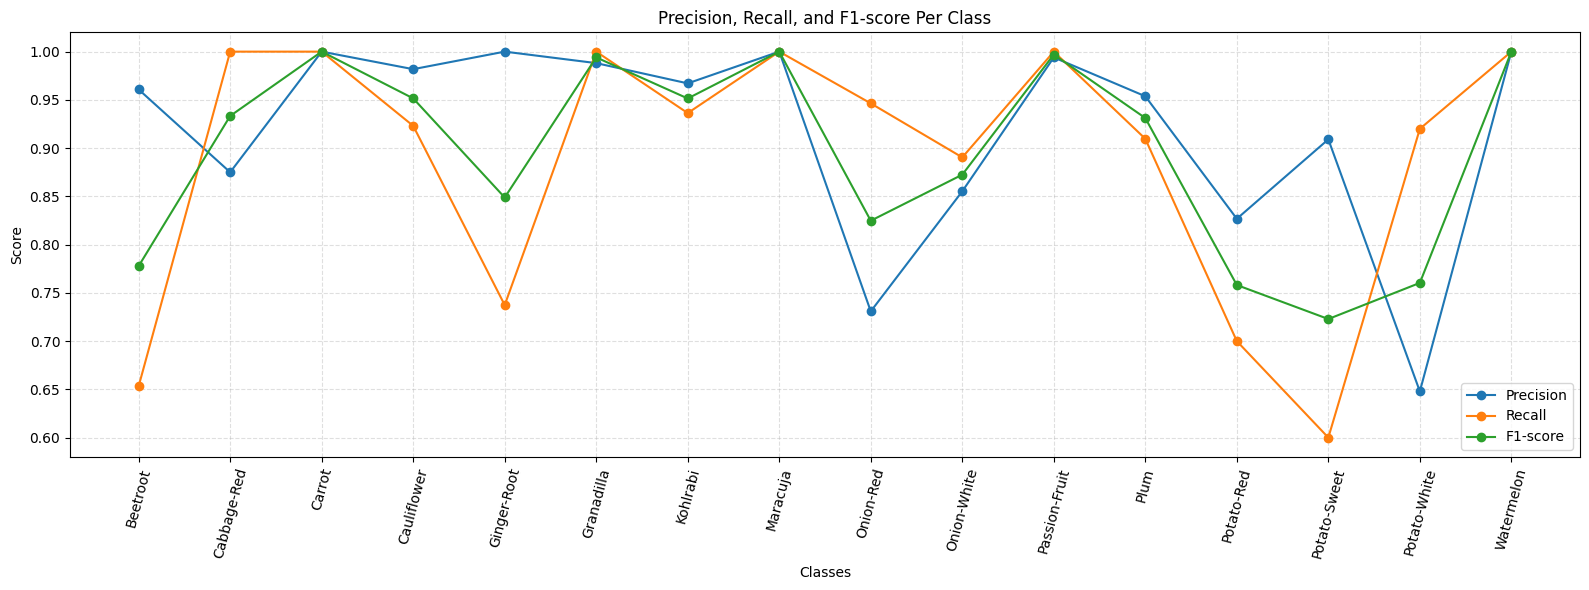

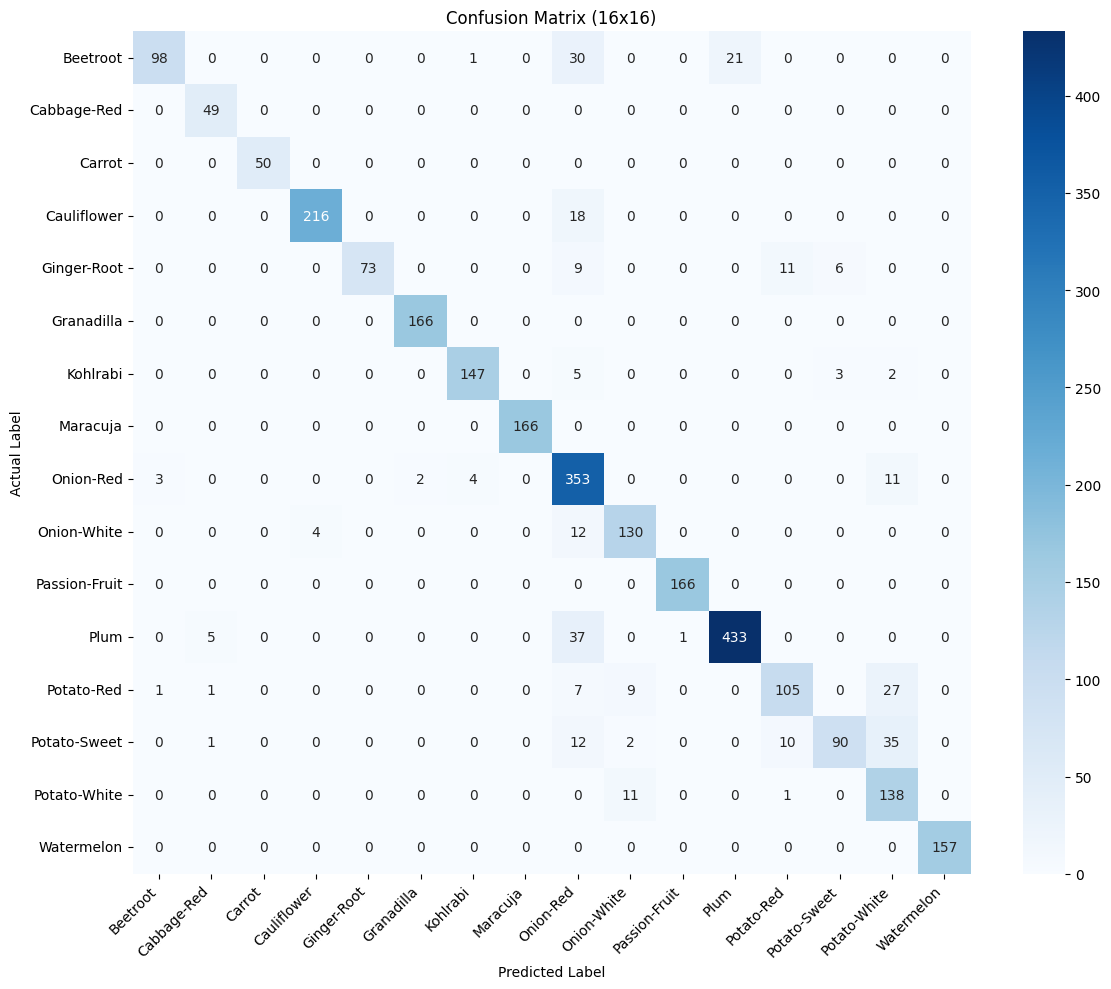

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Ambil output dari sklearn

y_pred = best_model.predict(X_test_pca)

print("Accuracy:", accuracy_score(Y_test_Clean, y_pred))
cls_report = classification_report(Y_test_Clean, y_pred, output_dict=True)
cm = confusion_matrix(Y_test_Clean, y_pred)

classes = list(cls_report.keys())[:-3]

precision = [cls_report[c]["precision"] for c in classes]
recall    = [cls_report[c]["recall"]    for c in classes]
f1        = [cls_report[c]["f1-score"]  for c in classes]

# 2. Grafik Line Plot

plt.figure(figsize=(16,6))
plt.plot(classes, precision, marker='o', label="Precision")
plt.plot(classes, recall, marker='o', label="Recall")
plt.plot(classes, f1, marker='o', label="F1-score")

plt.xticks(rotation=75)
plt.xlabel("Classes")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-score Per Class")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Confusion Matrix Heatmap

plt.figure(figsize=(12, 10))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (16x16)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Hasil Analisis

1. Akurasi model kami adalah 0.8936, yang berarti model mampu menebak dengan benar sekitar 89% gambar, atau sekitar 2530 gambar dari total 2839 gambar pada data test.
2. Beberapa kelas berhasil dikenali dengan sempurna oleh model, yaitu Carrot, Maracuja, Passion-Fruit, Watermelon, dan Granadilla. Hal ini terlihat dari nilai F1-score yang mencapai 1.00 pada kelas-kelas tersebut.
3. Kelas yang paling sulit dikenali oleh model adalah kelompok Potato (Potato-Red, Potato-Sweet, Potato-White). Hal ini karena nilai F1-score pada kelas-kelas tersebut merupakan yang paling rendah dibandingkan kelas lainnya, menandakan model sering keliru dalam membedakannya.
